<img src="./logo_UTN.svg" align="right" width="150" />

# Tarea Semanal 4

*Alumno: Lapilli Cañedo, Mariano Adrian*

## Consigna

<img src="./consigna.png" width="800" />

$. \ f_0 = 22 \ kHz; \ fs_1 = 17 \ kHz; \ fs_2 = 36 \ kHz$ 

$. \ Q = 5 \ siendo \ \omega_1 \ \omega_2 = \omega_{0}^2; \ \omega_2 - \omega_1 = \omega_0 / Q $ 


1. Obtener la plantilla de atenuación normalizada en frecuencia.  Indicar los valores de $\alpha_{max}$ y de $\alpha_{min}$

2. Obtener la función transferencia normalizada del prototipo pasa bajo que satisfaga el requerimiento del filtro pasa banda.

3. Aplicar el núcleo de transformación pasa banda y obtener la transferencia. Factorizar convenientemente para expresar en SOS.

4. Realizar la simulación numérica en python. Graficar la respuesta en frecuencia del filtro pasa banda total, y las de las SOS.

Bonus


+10 💎 Simulación Circuital del filtro pasa banda implementado mediante secciones pasivas separadas por seguidores de tensión activos. 

+10 💎 Dado el pasa bajo hallado en 2)  aplicar el núcleo de transformación pasa altos y obtener la transferencia.

+10 💎 Dado el pasa bajo hallado en 2) , implementarlo con pasivos y aplicar la transformación de Bruton. Obtener el valor numérico de D del $FDNR$ siendo $Z_{FDNR} = \frac{1}{s^{2}D}$


In [1]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
import control as ct
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
from pytc2.sistemas_lineales import pretty_print_lti

## Item 1

Para buscar la plantilla normalizada vamos a buscar los valores de nuestro filtro pasabanda primero, sabiendo que:

Norma de frecuencia: $  22kHz $

$\omega_1 \ \omega_2 = \omega_0^{2} \rightarrow \omega_1 = \frac{\omega_0^{2}}{\omega_2} \rightarrow \omega_1 = 0.9 $

$\omega_1 - \omega_2 = \frac{\omega_0}{Q} \rightarrow \frac{\omega_0^{2}}{\omega_2}  - \omega_2  = \frac{\omega_0}{Q} \rightarrow \omega_2 = 1.1$

$ B = \frac{\omega_0}{Q} = 0.2 $ 

Estos valores son normalizados. Ahora, los valores de $\alpha_{max}$ y de $\alpha_{min}$ son:

$\alpha_{max} = 0.5 \ dB$

$\alpha_{min} = 16 \ dB; \ para \ \omega_{s1}$

$\alpha_{min} = 24 \ dB; \ para \ \omega_{s2}$

## Item 2

Hay que buscar $\Omega_p$ y $\Omega_s$ de mi filtro Pasa Bajo prototipo

$$\Omega_p = \frac{1}{\beta} \frac{(\omega^2 - \omega_0^{2})}{\omega}$$

Obtengo $\Omega_{s1} = 2.64$  (la de $\alpha_{min} = 16 \ dB$) y $\Omega_{s2} = 5.08$  (la de $\alpha_{min} = 24 \ dB$) 

Luego:

$ \epsilon^2 = 0.122 $

Orden del filtro: 3 y $\omega_S = 2.64$

Desarrollo hecho en papel por mí:


<img src="./papel.png" width="800" />


Ahora vamos a sintetizar el filtro Chebyshev mediante simulación simbólica:

$$ T(s) = \frac{1}{1 + \epsilon^2 (C_n (\omega) )^2} ; \ \ C_3 = 4 \omega^3 - 3 \omega  $$




In [2]:
w = sp.symbols("w", real = True, posistive = True) 

Ts = 1 / ( 1 + 0.122 * ( 4 * w**3 - 3 * w )**2 )

Ts = Ts.expand()

print_latex(a_equal_b_latex_s('T(s)', Ts))

<IPython.core.display.Math object>

In [3]:
# Codigo solicitado a Gemini para hacerlo mónico 
w = sp.symbols("w", real=True, positive=True) # (Nota: corregí un pequeño typo de 'posistive' a 'positive')
Ts = 1 / ( 1 + 0.122 * ( 4 * w**3 - 3 * w )**2 )
Ts = Ts.expand()

# --- Nuevo código para hacerlo mónico ---

# 1. Separar numerador y denominador
n, d = sp.fraction(Ts)

# 2. Encontrar el coeficiente principal (Leading Coefficient) respecto a 'w'
coef_principal = sp.LC(d, w)

# 3. Dividir ambos por el coeficiente principal (expandimos abajo para que se distribuya)
Ts_monico = (n / coef_principal) / sp.expand(d / coef_principal)

# Imprimir el resultado
print_latex(a_equal_b_latex_s('T(s)', Ts_monico))

<IPython.core.display.Math object>

Teniendo en cuenta que $ \omega = \frac{s}{j}$

$$T(s) = \frac{-0.512}{s^{6} + 1.5 s^{4} + 0.5625 s^{2} - 0.512}$$

/home/mariano/marianoTC2/lib/python3.12/site-packages/scipy/signal/_ltisys.py:603: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


array([-0.31322505+1.02192456j, -0.31322505-1.02192456j,
        0.31322505+1.02192456j,  0.31322505-1.02192456j,
       -0.62645011+0.j        ,  0.62645011+0.j        ])

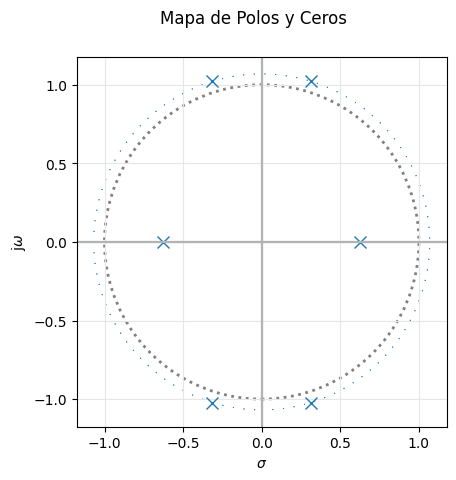

In [15]:
#Busco polos y ceros y defino numericamente los polos de la transferencia

num = [0, -0.5122]

den = [1, 0, 1.5, 0, 0.5625, 0, -0.5122]

H = sig.TransferFunction(num, den)

pzmap(H)

plt.show

np.roots(den)

Los polos están en:

$ s = -0.3132\pm \ j \ 1.0219 $

$ s = -0.6265  $

In [14]:
# Simulacion simbolica para hallar la transferencia

s = sp.symbols("s", real = True, posistive = True) 

a1 = 0.6265

b1 = 0.3132

b2 = 1.0219

mod2 = b1**2 + b2**2

A = ( a1 ) / ( s + a1 )

B = B.expand()

print('Transferencia de etapa de primer orden: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', A))
print('')

B = ( mod2 ) / ( s**2 + 2 * b1 * s + mod2 )

B = B.expand()

print('Transferencia de etapa de segundo orden: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', B))
print('')

Ts = A * B

Ts = Ts.expand()

print('Transferencia de filtro Pasa Bajo prototipo: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', Ts))



Transferencia de etapa de primer orden: 



<IPython.core.display.Math object>


Transferencia de etapa de segundo orden: 



<IPython.core.display.Math object>


Transferencia de filtro Pasa Bajo prototipo: 



<IPython.core.display.Math object>

## Item 3

Aplicamos el nucleo pasabanda $ s' = Q \frac{s^2 + 1}{s}$ con $ Q = 5 $

In [6]:
# Simulacion simbolica para hallar la transferencia pasabanda

s = sp.symbols("s", real = True, posistive = True) 

s = 5 * ( ( 1 ) / ( s ) )

a1 = 0.6265

b1 = 0.3132

b2 = 1.0219

mod2 = b1**2 + b2**2

A = ( a1 ) / ( s + a1 )

A = A.cancel()

print('Transferencia de etapa de primer orden (transformada): ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', A))
print('')

B = ( mod2 ) / ( s**2 + 2 * b1 * s + mod2 )

B = B.cancel()

print('Transferencia de etapa de segundo orden (transformada): ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', B))
print('')

Ts = A * B

Ts = Ts.cancel()

print('Transferencia de filtro Pasa Banda: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', Ts))

Transferencia de etapa de primer orden (transformada): 



<IPython.core.display.Math object>


Transferencia de etapa de segundo orden (transformada): 



<IPython.core.display.Math object>


Transferencia de filtro Pasa Banda: 



<IPython.core.display.Math object>

## Item 4

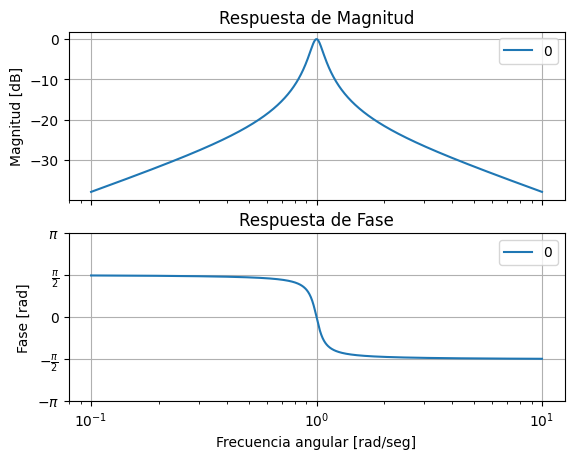

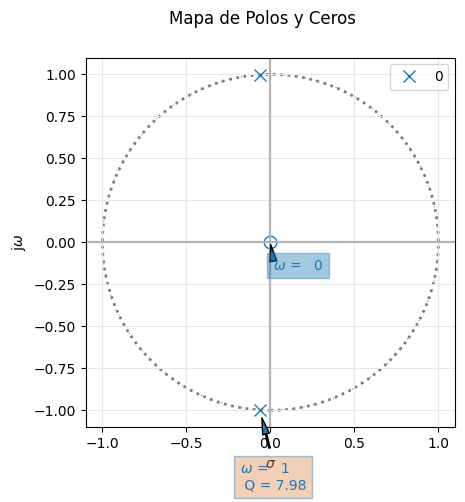

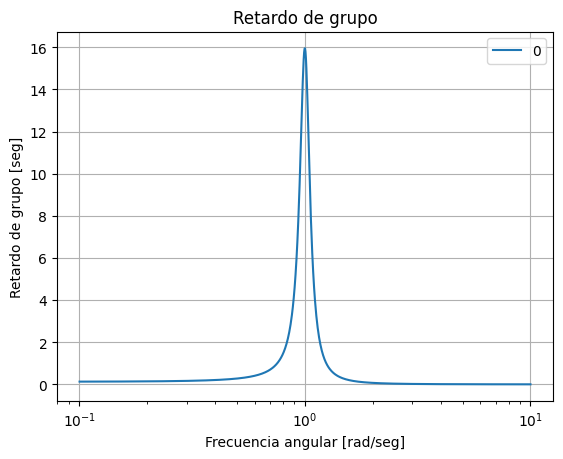

In [7]:
# Simulación numérica SOS primer orden

num = [0.6265, 0]
den = [5, 0.6265, 5]

H = sig.TransferFunction(num, den)

_ = analyze_sys(H)

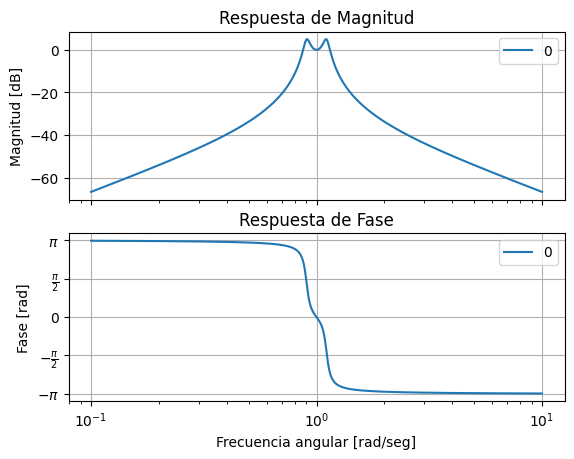

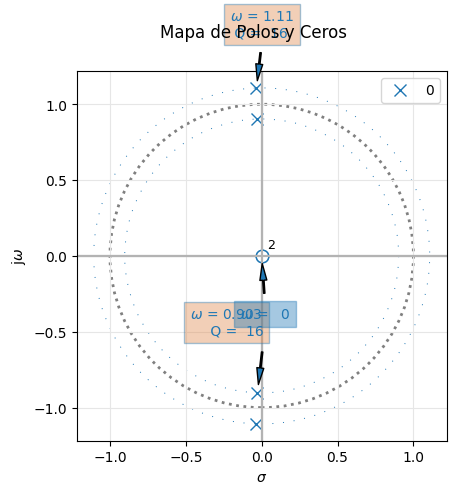

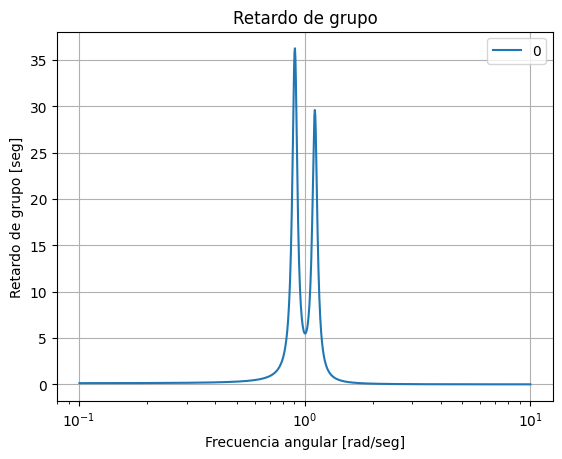

In [8]:
# Simulación numérica SOS segundo orden

num = [1.1424, 0, 0]
den = [25, 3.132, 51.1424, 3.132, 25]

H = sig.TransferFunction(num, den)

_ = analyze_sys(H)

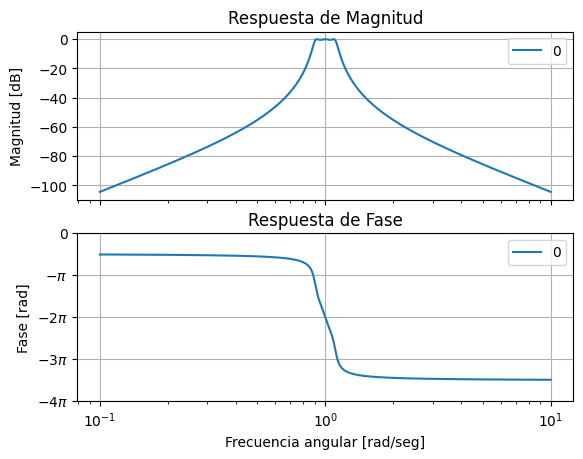

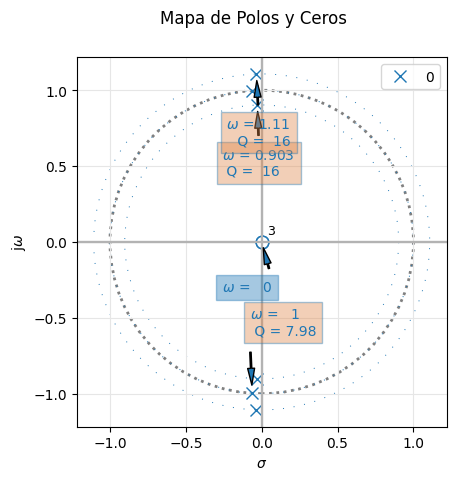

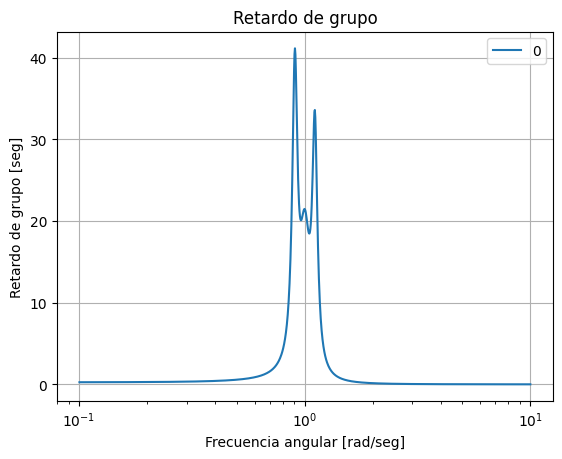

In [9]:
# Simulación numérica SOS pasa banda total

num = [0.7157, 0, 0, 0]
den = [125, 31.3225, 382.6741, 63.3607, 382.6741, 31.3225, 125]

H = sig.TransferFunction(num, den)

_ = analyze_sys(H)

## Items Bonus

Para la simulación circuital me encuentro con dos secciones pasabanda, una de orden 2 y otra de 4. Lo que puedo es factorizar la sección de orden 4 para así tener 3 secciones de orden 2 y poder sintetizar mas fácil.

In [10]:
# Busco polos para sintetizar

num = [1.1424, 0, 0]
den = [25, 3.132, 51.1424, 3.132, 25]

H = sig.TransferFunction(num, den)

np.roots(den)

array([-0.03450558+1.10691625j, -0.03450558-1.10691625j,
       -0.02813442+0.90253369j, -0.02813442-0.90253369j])

In [11]:
#Simulación simbólica del pasabanda

s = sp.symbols("s", real = True, posistive = True) 

a1 = 0.03451

a2 = 1.1069

b1 = 0.02813

b2 = 0.9025

mod1 = a1**2 + a2**2

mod2 = b1**2 + b2**2

A = ( 2 * a1 * s  ) / ( s**2 + 2 * a1 * s + mod1 )

A = A.cancel()

print('Transferencia de etapa pasabanda seccionada 1: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', A))
print('')

B = ( 2 * b1 * s ) / ( s**2 + 2 * b1 * s + mod2 )

B = B.cancel()

print('Transferencia de etapa pasabanda seccionada 2: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', B))
print('')

Transferencia de etapa pasabanda seccionada 1: 



<IPython.core.display.Math object>


Transferencia de etapa pasabanda seccionada 2: 



<IPython.core.display.Math object>

Voy a armar el sistema con circuitos del tipo Ackerberg-Mossberg en cascada:

$$T(s) = \frac{s \frac{1}{ R_2 C }}{s^{2} + s \frac{1}{ R_2 C } + \frac{1}{ (R_3 C)^2 }}$$

<img src="./simucirc.png" width="1000" />

<img src="./simutrans.png" width="1000" />


### Conclusión: No se bien porque se me desplazó en frecuencia al principio (preguntar en clase)

In [12]:
# Obtengo la transferencia Pasa Alto mediante el núcleo de transformación

s = sp.symbols("s", real = True, posistive = True) 

s = 1 / s

a1 = 0.6265

b1 = 0.3132

b2 = 1.0219

mod2 = b1**2 + b2**2

A = ( a1 ) / ( s + a1 )

B = B.cancel()

print('Transferencia de etapa de primer orden: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', A))
print('')

B = ( mod2 ) / ( s**2 + 2 * b1 * s + mod2 )

B = B.cancel()

print('Transferencia de etapa de segundo orden: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', B))
print('')

Ts = A * B

Ts = Ts.cancel()

print('Transferencia de filtro Pasa Bajo prototipo: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', Ts))

Transferencia de etapa de primer orden: 



<IPython.core.display.Math object>


Transferencia de etapa de segundo orden: 



<IPython.core.display.Math object>


Transferencia de filtro Pasa Bajo prototipo: 



<IPython.core.display.Math object>

Vamos a implementar un circuito girador cuya topología es:

<img src="./girador.png" width="1000" />

Y la impedancia característica es: 

$$Z(s) = \frac{Z_1 Z_3 R_5}{R_1 R_2}$$

Si $Z_1$ y $Z_3$ son capacitores, el resultado de la impedancia

$$Z(s) = \frac{R_5}{s^{2} C_1 C_3 R_1 R_2} \rightarrow Z(s) = \frac{1}{s^{2} D}; D =  \frac{C_1 C_3 R_1 R_2}{ R_5 }$$

In [13]:
# Obtengo la transferencia Pasa Alto mediante el núcleo de transformación

s = sp.symbols("s", real = True, posistive = True) 
D = sp.symbols("D", real = True, posistive = True) 

s = 1 / s**2 * D

a1 = 0.6265

b1 = 0.3132

b2 = 1.0219

mod2 = b1**2 + b2**2

A = ( a1 ) / ( s + a1 )

B = B.cancel()

print('Transferencia de etapa de primer orden: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', A))
print('')

B = ( mod2 ) / ( s**2 + 2 * b1 * s + mod2 )

B = B.cancel()

print('Transferencia de etapa de segundo orden: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', B))
print('')

Ts = A * B

Ts = Ts.cancel()

print('Transferencia de filtro Pasa Bajo prototipo: ') 
print('')
print_latex(a_equal_b_latex_s('T(s)', Ts))

Transferencia de etapa de primer orden: 



<IPython.core.display.Math object>


Transferencia de etapa de segundo orden: 



<IPython.core.display.Math object>


Transferencia de filtro Pasa Bajo prototipo: 



<IPython.core.display.Math object>